In [43]:
import pandas as pd
import numpy as np

In [44]:
df=pd.read_csv("IMDB Dataset.csv")

In [45]:
df.shape

(50000, 2)

In [46]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [47]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.shape

(49582, 2)

## Text pre-processing

### Regex (Regular Expression) library is used for Text pre-processing

#### Step 1 - Lowercase conversion

In [50]:
df["review"]=df["review"].str.lower()

### Step 2 - Remove URLs

In [51]:
import re

def remove_urls(text):
    text=re.sub(r"http\S+","",text)
    return text

df["review"]=df["review"].apply(remove_urls)

### Step3 - Remove HTML Tags

In [52]:
def remove_tags(text):
    text=re.sub(r"<.*?>","",text)
    return text

df["review"]=df["review"].apply(remove_tags)

### Step4 - Remove Punctuations

In [53]:
def remove_punctuations(text):
    text=re.sub(r"[^A-Z-a-z-0-9\s]","",text)
    return text


df["review"]=df["review"].apply(remove_punctuations)

### Step5 - Removing Stopwords

In [54]:
import nltk

nltk.download("punkt") #for tokenization
nltk.download("punkt_tab")
nltk.download("stopwords")

from nltk.tokenize import word_tokenize #Token creation
from nltk.corpus import stopwords #pre-defined stopwords of English language

[nltk_data] Downloading package punkt to /Users/aksha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/aksha/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/aksha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [55]:
def remove_stopwords(text):
    tokens=word_tokenize(text)
    stop_words=stopwords.words("english")

    for word in tokens:
        if word in stop_words:
            text=text.replace(word,"")
    return text

df["review"]=df["review"].apply(remove_stopwords)

In [56]:
df.head()

,review,sentiment
0,e revewers nted wtchg 1 oz epode ll ho...,positive
1,wderful ltle producti filming technique un...,positive
2,thought ths wderful wy spend tme o hot s...,positive
3,bsclly res fmly lttle boy jke thks res zom...,negative
4,petter mtte love time mey vully stunng fi...,positive


### Step6 - Stemming

In [57]:
from nltk.stem import PorterStemmer

def stemming(text):
    ps=PorterStemmer()
    stemmed_words=[]

    for token in word_tokenize(text):
        stemmed_token=ps.stem(token)
        stemmed_words.append(stemmed_token)

    return " ".join(stemmed_words)

df["review"]=df["review"].apply(stemming)

In [58]:
df.head()

,review,sentiment
0,e revew nted wtchg 1 oz epod ll hook y rght ex...,positive
1,wder ltle producti film techniqu unssuming- ol...,positive
2,thought th wder wy spend tme o hot summer week...,positive
3,bsclli re fmli lttle boy jke thk re zomb close...,negative
4,petter mtte love time mey vulli stunng film wt...,positive


### Encoding the sentiment (target)

In [59]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df["sentiment"]=le.fit_transform(df["sentiment"])

In [60]:
y=df["sentiment"]

y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 49582, dtype: int64

### Vectorization

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf=TfidfVectorizer(max_features=5000)

X=tf.fit_transform(df["review"])

In [62]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4089835 stored elements and shape (49582, 5000)>
  Coords	Values
  (0, 3540)	0.055810426788625835
  (0, 2872)	0.09442051486751893
  (0, 4942)	0.11536236701428403
  (0, 3002)	0.47523946297148006
  (0, 1286)	0.1369644482157359
  (0, 2291)	0.049704567432585944
  (0, 1931)	0.07963556917013008
  (0, 3553)	0.0972499401463245
  (0, 1373)	0.06228331805590231
  (0, 1962)	0.062064369218173245
  (0, 1626)	0.07498584827489718
  (0, 4369)	0.04225518614138888
  (0, 4172)	0.17862053729650143
  (0, 3698)	0.03374681795852441
  (0, 4739)	0.27103272054846606
  (0, 3805)	0.04427712881437228
  (0, 4770)	0.11779910802253869
  (0, 1741)	0.037668234561015874
  (0, 4497)	0.07703770817875899
  (0, 3857)	0.17645986219444515
  (0, 1636)	0.0612889833261882
  (0, 1862)	0.07168410639133287
  (0, 3334)	0.06464994896134221
  (0, 3337)	0.08439803198559376
  (0, 3437)	0.07923058519499719
  :	:
  (49581, 4139)	0.07038418927610458
  (49581, 4893)	0.090086686215

### Dataset and DataLoader

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [64]:
X_train.shape

(39665, 5000)

In [65]:
X_test.shape

(9917, 5000)

In [66]:
type(X)

scipy.sparse._csr.csr_matrix

In [67]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


In [68]:
X_train=X_train.toarray()
X_test=X_test.toarray()

In [69]:
trainset=TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train.values).float(),
)

testset=TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(y_test.values).float(),
)

In [70]:
train_loader=DataLoader(trainset,batch_size=64,shuffle=True)
test_loader=DataLoader(testset,batch_size=64,shuffle=True)

In [71]:

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)   # new
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        
        out, _ = self.rnn(x) # h0 defaults to zeros automatically Two values - 1) #hidden state of all timesteps ==>(batch,seq_len,hidden size) 2) Final hidden state of last timestep
       
        out = self.dropout(out[:, -1, :])    # apply dropout before final layer # take last timestep's output

        out = self.fc(out)
        return out

In [72]:
input_size=X_train.shape[1]
hidden_size = 64
num_layers = 1


model=RNN(input_size, hidden_size, num_layers)

### Loss Function and Optimzer

In [73]:
import torch.optim as optim

criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001, weight_decay=1e-4)

### Training and Evaluation

In [74]:
epochs = 10
train_losses = []
val_losses = []
patience = 3 

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # total training loss for one epoch

    for Xb, yb in train_loader:  # Xb - features of one batch, yb - labels of one batch
        optimizer.zero_grad()

        Xb = Xb.unsqueeze(1)  # (batch, features) -> (batch, 1, features) add singleton seq_len dim

        outputs = model(Xb)                          # forward propagation -> (batch_size, 1)
        outputs = torch.sigmoid(outputs.squeeze())    # (batch_size,) -> probability

        loss = criterion(outputs, yb)  # loss computation
        loss.backward()                # backpropagation
        optimizer.step()               # param update

        running_loss += loss.item()    # loss tensor value -> python float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  # no gradient computation
        for Xb, yb in test_loader:
            Xb = Xb.unsqueeze(1)

            outputs = model(Xb)
            outputs = torch.sigmoid(outputs.squeeze())

            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)  # len(test_loader) = number of batches
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss={epoch_train_loss:.4f} & val loss={epoch_val_loss:.4f}")

    # save model only when validation loss improves
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

epoch 1/10 ==> train loss=0.4254 & val loss=0.3154
epoch 2/10 ==> train loss=0.2828 & val loss=0.3045
epoch 3/10 ==> train loss=0.2667 & val loss=0.3079
epoch 4/10 ==> train loss=0.2613 & val loss=0.3126
epoch 5/10 ==> train loss=0.2578 & val loss=0.3179
Early stopping triggered at epoch 5


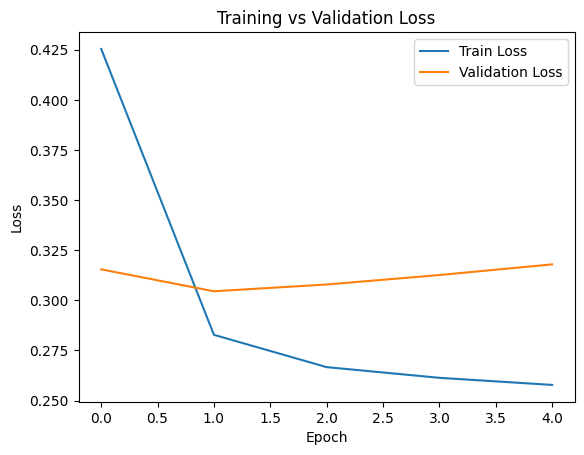

In [75]:
import matplotlib.pyplot as plt

losses_df = pd.DataFrame({
    "Train Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(losses_df["Train Loss"], label="Train Loss")
plt.plot(losses_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [76]:
# Reload best checkpoint before final evaluation
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [77]:
from sklearn.metrics import accuracy_score, classification_report

predicted_labels = []
actual_labels = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)  # (batch, features) -> (batch, 1, features)

        outputs = model(Xb)                         # forward pass -> (batch_size, 1)
        outputs = torch.sigmoid(outputs.squeeze())  # (batch_size,) -> probability

        predicted = (outputs >= 0.5).long()         # threshold probability -> class 0 or 1

        predicted_labels.extend(predicted.numpy().flatten())
        actual_labels.extend(yb.numpy().flatten())

print("Accuracy score:", accuracy_score(actual_labels, predicted_labels))
print(classification_report(actual_labels, predicted_labels, target_names=["Class 0", "Class 1"]))

Accuracy score: 0.8691136432388827
              precision    recall  f1-score   support

     Class 0       0.88      0.86      0.87      4939
     Class 1       0.86      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



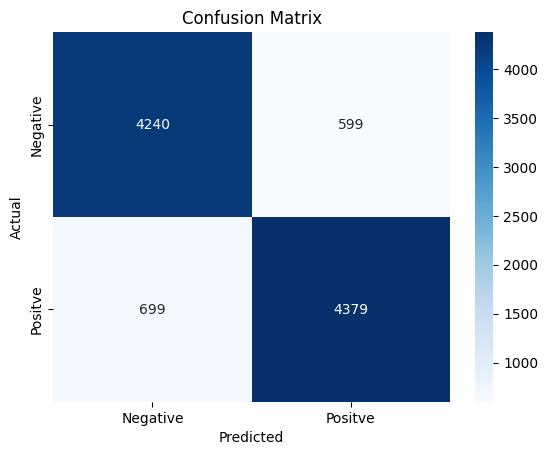

In [78]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["Negative", "Positve"]

cm = confusion_matrix(predicted_labels, actual_labels)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### LSTM (Long short term Memory)

In [79]:

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)              # h0, c0 default to zeros automatically
        out = self.dropout(out[:, -1, :])  # take last timestep's output
        out = self.fc(out)
        return out


In [80]:
input_size = X_train.shape[1]  # number of features per timestep

model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=1, dropout=0.3)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


In [81]:
epochs = 10
patience = 3
patience_counter = 0

train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for Xb, yb in train_loader:
        optimizer.zero_grad()

        Xb = Xb.unsqueeze(1)  # (batch, features) -> (batch, 1, features)

        outputs = model(Xb)                          # forward pass -> (batch_size, 1)
        outputs = torch.sigmoid(outputs.squeeze())    # (batch_size,) -> probability

        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.unsqueeze(1)

            outputs = model(Xb)
            outputs = torch.sigmoid(outputs.squeeze())

            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss={epoch_train_loss:.4f} & val loss={epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model1.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break


epoch 1/10 ==> train loss=0.4592 & val loss=0.3220
epoch 2/10 ==> train loss=0.2881 & val loss=0.3090
epoch 3/10 ==> train loss=0.2689 & val loss=0.3079
epoch 4/10 ==> train loss=0.2617 & val loss=0.3101
epoch 5/10 ==> train loss=0.2585 & val loss=0.3145
epoch 6/10 ==> train loss=0.2563 & val loss=0.3144
Early stopping triggered at epoch 6


In [82]:
# Reload best checkpoint before final evaluation
model.load_state_dict(torch.load("best_model1.pt"))

<All keys matched successfully>

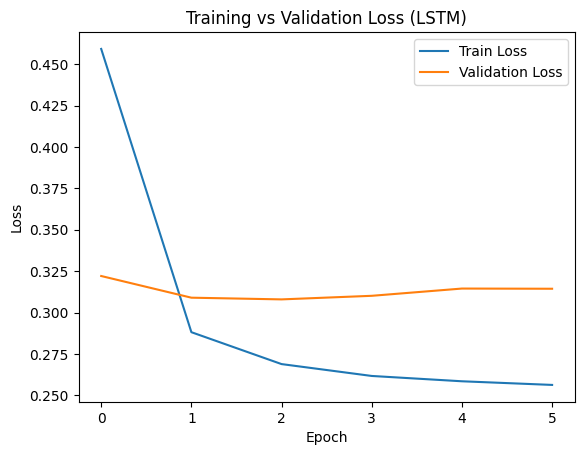

In [83]:
import matplotlib.pyplot as plt

losses_df = pd.DataFrame({
    "Train Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(losses_df["Train Loss"], label="Train Loss")
plt.plot(losses_df["Validation Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (LSTM)")
plt.legend()
plt.show()

In [84]:
from sklearn.metrics import accuracy_score, classification_report

predicted_labels = []
actual_labels = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)  # (batch, features) -> (batch, 1, features)

        outputs = model(Xb)                         # forward pass -> (batch_size, 1)
        outputs = torch.sigmoid(outputs.squeeze())  # (batch_size,) -> probability

        predicted = (outputs >= 0.5).long()         # threshold probability -> class 0 or 1

        predicted_labels.extend(predicted.numpy().flatten())
        actual_labels.extend(yb.numpy().flatten())

print("Accuracy score:", accuracy_score(actual_labels, predicted_labels))
print(classification_report(actual_labels, predicted_labels, target_names=["Negative", "Positive"]))

Accuracy score: 0.8655843501058788
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4939
    Positive       0.86      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



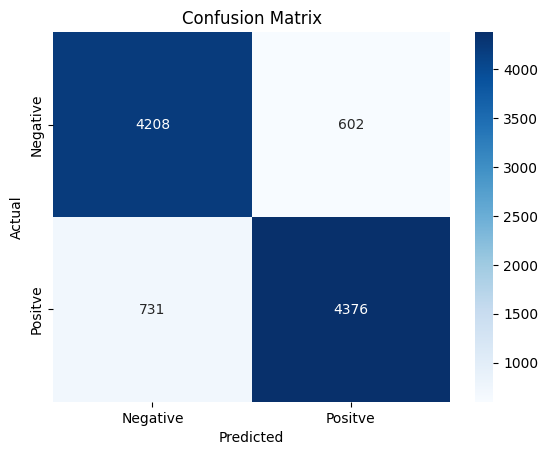

In [85]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["Negative", "Positve"]

cm = confusion_matrix(predicted_labels, actual_labels)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()